About the homework: In some tasks, in addition to writing code, answers to questions and conclusions are required (there are special Markdown cells marked with **Answer**).

The ability to analyze the results of experiments is an important skill. Therefore, answers carry more weight than the code: the code accounts for 30% of the task grade, while answers to questions account for 70%.

**Reminder:** Plagiarism is prohibited. Use of AI without mentioning how and in which parts it was used is also prohibited. If plagiarism or dishonest use of AI is revealed, the assignment is graded with 0.

In [750]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

Let's work with Titanic dataset again: Download `train.csv` file from https://www.kaggle.com/c/titanic/data?select=train.csv

In [752]:
df = pd.read_csv('train.csv')
df.sample(4)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
865,866,1,2,"Bystrom, Mrs. (Karolina)",female,42.0,0,0,236852,13.0000,NaN,S
873,874,0,3,"Vander Cruyssen, Mr. Victor",male,47.0,0,0,345765,9.0000,NaN,S
728,729,0,2,"Bryhl, Mr. Kurt Arnold Gottfrid",male,25.0,1,0,236853,26.0000,NaN,S
534,535,0,3,"Cacic, Miss. Marija",female,30.0,0,0,315084,8.6625,NaN,S


# Task 1 (1 point)

Split dataFrame into train and test. Set `test_size=0.3, random_state=0`

In [755]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.3, random_state=0)

Let's start preprocessing the features:



*   Drop features with $>40%$ missing values and `'PassengerId'`
*   Fill missing values with median (for numerical features) and mode (for categorical features)



In [757]:
df_train.drop('PassengerId', axis = 1, inplace=True)
df_test.drop('PassengerId', axis = 1, inplace=True)
df_train.dropna(axis = 1, thresh = len(df_train) - 40, inplace = True)
df_test.dropna(axis = 1, thresh = len(df_test) - 40, inplace = True)

values = {"Survived": df["Survived"].mode().iloc[0], "Pclass": df["Pclass"].mode().iloc[0], "Sex": df["Sex"].mode().iloc[0], \
          "Age": df["Age"].median(), "SibSp": df["SibSp"].median(), "Parch": df["Parch"].median(), "Fare": df["Fare"].median(), \
          "Cabin": df["Cabin"].mode().iloc[0], "Embarked": df["Embarked"].mode().iloc[0]} # I do not touch "Name" and "Ticket" variables, 
                                                                                        # since they are all unique for each passenger and 
                                                                                        # equating them to mode would make no sense. Although 
                                                                                        # they have no NA's anyway.
df_train.fillna(values, inplace=True)
df_test.fillna(values, inplace=True)

How many features do we have now? (Do not count `'Survived'` - this will be target)

In [759]:
print(df_train.columns)
print(df_test.columns)
print("Not counting 'Survived', there are 8 features left for both training and testing datasets. These are 'Pclass', 'Name', \
'Sex', 'SibSp', 'Parch', 'Ticket', 'Fare', and 'Embarked'. We dropped 'PassengerId' column manually, since it was of no use for our analysis, \
'Age' and 'Cabin' columns were dropped due to a presense of more than 40 missing values.")

Index(['Survived', 'Pclass', 'Name', 'Sex', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')
Index(['Survived', 'Pclass', 'Name', 'Sex', 'SibSp', 'Parch', 'Ticket', 'Fare',
       'Embarked'],
      dtype='object')
Not counting 'Survived', there are 8 features left for both training and testing datasets. These are 'Pclass', 'Name', 'Sex', 'SibSp', 'Parch', 'Ticket', 'Fare', and 'Embarked'. We dropped 'PassengerId' column manually, since it was of no use for our analysis, 'Age' and 'Cabin' columns were dropped due to a presense of more than 40 missing values.


# Task 2 (2 points)

Now, let's use one-hot-encoding to encode columns with type `'object'`:



*   Fit the Encoder on train data
*   Apply to train and test
*   Check, how many new features we have now

Describe the problems you have faced (hint: one of the problems - `ValueError` and the solution will be to set `handle_unknown` in the `OneHotEncoder`). Explain, why did they occur, which impact may they have  on the training process?

In [763]:
from sklearn.preprocessing import OneHotEncoder

train_cat = df_train.select_dtypes(include = "object")
test_cat = df_test.select_dtypes(include = "object")
ohe_train = OneHotEncoder(drop = "first", handle_unknown = "ignore")
ohe_test = OneHotEncoder(drop = "first", handle_unknown = "ignore")
ohe_train.fit(train_cat)
ohe_test.fit(test_cat)
X_train_categorical_encoded = ohe_train.transform(train_cat).toarray()
X_test_categorical_encoded  = ohe_test.transform(test_cat).toarray()

X_train_pd_enc = pd.DataFrame(X_train_categorical_encoded, columns = ohe_train.get_feature_names_out(train_cat.columns))
X_test_pd_enc = pd.DataFrame(X_test_categorical_encoded, columns = ohe_test.get_feature_names_out(train_cat.columns))

print(X_train_pd_enc.shape)
(X_test_pd_enc.shape)

(623, 1134)


(268, 517)

**Answer** From the shape of the resulting DataFrame with one-hot encoded categorical variables, it can be seen that the number of features becomes enormously huge, even bigger than the amount of observations. This is not a surprise in the light of the "Name" and "Ticket" variables being present as categorical features in the dataset. Both features have unique values (at least if we assume that multiple passengers cannot travel by one ticket) for each observation, and since One-Hot Encoder takes each unique value and creates a separate column for it (in out case, also dropping first columns for unique values in each initial unique features), and for columns with only unique values it does the same thing (bringing up an error that we ignored in defining parameters for our OneHotEncoder), thus creating a non-logical hundreds and hundreds of irrelevant columns. We cannot conduct any statistical calculation based upon solely unique occurencies, and thus, this hundreds and hundreds of features are of no use for our analysis (and we also know immediately that each passenger will have 1's in only one column created from "Name" and in only columns created from "Ticket"). Thus, it would be better to remove these columns from out further analysis. We can hypothetically extract some information from "Name" or "Ticket", for example, look at how well did all women named Suzan did in surviving the Titanic catastrophe, but it would require changing of the feature's values to first names-only and, essentially, would require a separate analysis. Therefore, once again, in this analysis, the "Name" and "Ticket" can be dropped.


Drop the columns `'Name','Ticket'` and try again.

In [766]:
df_train.drop(["Name", "Ticket"], axis = 1, inplace=True)
df_test.drop(["Name", "Ticket"], axis = 1, inplace=True)


train_cat = df_train.select_dtypes(include = "object")
test_cat = df_test.select_dtypes(include = "object")

ohe_train = OneHotEncoder(drop = "first")
ohe_test = OneHotEncoder(drop = "first")
ohe_train.fit(train_cat)
ohe_test.fit(test_cat)
X_train_categorical_encoded = ohe_train.transform(train_cat).toarray()
X_test_categorical_encoded  = ohe_test.transform(test_cat).toarray()

X_train_pd_enc = pd.DataFrame(X_train_categorical_encoded, columns = ohe_train.get_feature_names_out(train_cat.columns))
X_test_pd_enc = pd.DataFrame(X_test_categorical_encoded, columns = ohe_test.get_feature_names_out(test_cat.columns))

Combine numerical features and encoded categorical and split the data into `X` (objects with features) and `y` (target - `Survived` column) for train and test data.

In [768]:
y_train = df_train["Survived"]
y_test = df_test["Survived"]

df_train.drop("Survived", axis = 1, inplace = True)
df_test.drop("Survived", axis = 1, inplace = True)

X_train = np.concatenate([df_train.drop(df_train.select_dtypes(include = "object").columns.to_list(), axis = 1),
                     X_train_pd_enc], axis=1)
X_test = np.concatenate([df_test.drop(df_train.select_dtypes(include = "object").columns.to_list(), axis = 1),
                     X_test_pd_enc], axis=1)

print(X_train.shape)
print(X_test.shape)

(623, 7)
(268, 7)


# Task 3 (2 points)

Which metric will be better suitable for our machine learning task? (We want to predict if passenger survived or not). Explain your choice.

In [771]:
print("Class ratio for the training dataset:", y_train[(y_train == 1)].count() / y_train[(y_train == 0)].count()) 
print("Class ratio for the testing dataset:", y_test[(y_test == 1)].count() / y_test[(y_test == 0)].count())
print("Class ratio for the general dataset:", len(df[(df["Survived"] == 1)]) / len(df[(df["Survived"] == 0)])) 

Class ratio for the training dataset: 0.6351706036745407
Class ratio for the testing dataset: 0.5952380952380952
Class ratio for the general dataset: 0.6229508196721312


**Answer** To understanding what evaluation metric will be most suitable in our case, we should look at, first, if we are to conduct multiclass or binary logistic regression, if we are to evaluate probabilities or predictions, and if the data is unbalanced. In the task, we should predict values for a binary variable "Survived", which can be 1 if the passenger survived or 0 if she didn't. This means that we a conducting a regular binary (not multiclass) logistic regression, and do not need to use ROC AUC for evaluating probabilities. Thus, Accuracy, True Positive Rate, False Positive Rate, Precision, Recall or f1-score combining precision and recall metrics can be effectively used. However, from the class ratios for training, testing, and general datasets printed above we can see that the dependent variable is rather balanced for all datasets, and thus, the more common metric of accuracy can be effectively used. Thus, I will be using this metric in my analysis.


Fit logistic regression and evaluate the performance on train and test data (using metric you chose)

In [774]:
from sklearn.metrics import accuracy_score

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train) # Here and further, I am fitting the models only with values from the training dataset. Maybe this is wrong
# (from the point of view of the task) and I should've been creating two separate fits for each dataset throughout all of my steps, 
# but in this case I do not see any reason for initial split of the original dataset. Thus, I fit the model with values from the 
# training dataset and make predictions for training dependent variable's and testing dependent variable's values. At least, this is
# my understanding of the task.
y_pred_train = lr.predict(X_train)
y_pred_test = lr.predict(X_test)

print(accuracy_score(y_train,  y_pred_train))
print(accuracy_score(y_test,  y_pred_test))

0.7913322632423756
0.7947761194029851


Now, use `GridSearchCV` to find better hyperparameters (to avoid warnings about total number of iterations, set `max_iter=1000`)

In [776]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = {'C' : np.logspace(-12, 10, 30) }

clf_lr = GridSearchCV(LogisticRegression(max_iter=1000), params, cv=3, scoring='accuracy')
clf_lr.fit(X_train, y_train)
print(accuracy_score(y_train,  clf_lr.predict(X_train)))
print(accuracy_score(y_test,  clf_lr.predict(X_test)))
print("Best hyperparameter:", clf_lr.best_estimator_)

0.7929373996789727
0.7947761194029851
Best hyperparameter: LogisticRegression(C=7.880462815669905, max_iter=1000)


# Task 4 (2 points)

Fit a decision tree using `GridSearchCV`. Use the parameter grid for hyperparameters `max_depth, min_samples_split, min_samples_leaf`

In [779]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

params = { 'max_depth' : [1, 2, 5, 10, None], 
          'min_samples_split' : [2, 5, 10],
           'min_samples_leaf' : [1, 2, 3, 4]
}

clf_tree = GridSearchCV(DecisionTreeClassifier(), params, cv=3, scoring='accuracy')
clf_tree.fit(X_train, y_train)
print(accuracy_score(y_train,  clf_tree.predict(X_train)))
print(accuracy_score(y_test,  clf_tree.predict(X_test)))
print("Best hyperparameters:", clf_tree.best_estimator_)

0.8346709470304976
0.7873134328358209
Best hyperparameters: DecisionTreeClassifier(max_depth=5, min_samples_split=5)


Now, use soft voting strategy to combine logistic regression and decision tree (use the ones with the best hyperparameters). Measure the quality on train and test data. Did the quality improve?

In [781]:
from sklearn.ensemble import VotingClassifier

models_names = [
    ('Logistic Regression', clf_lr),
    ('Decision Tree', clf_tree),
]

voting = VotingClassifier(models_names,
                          voting='soft'
                          )

voting.fit(X_train, y_train)

print("Quality for train data is now:", accuracy_score(y_train, voting.predict(X_train)))
print("Quality for test data is now:", accuracy_score(y_test, voting.predict(X_test)))
print("Increase in quality for train data and Logistic regression is equal to", accuracy_score(y_train, voting.predict(X_train)) \
      - accuracy_score(y_train,  y_pred_train))
print("Increase in quality for test data and Logistic regression is equal to", accuracy_score(y_test, voting.predict(X_test)) \
      - accuracy_score(y_test,  y_pred_test))
print("Increase in quality for train data and Decision Tree Classifier is equal to", accuracy_score(y_train, voting.predict(X_train)) \
      - accuracy_score(y_train,  clf_lr.predict(X_train)))
print("Increase in quality for test data and Decision Tree Classifier is equal to", accuracy_score(y_test, voting.predict(X_test)) \
      - accuracy_score(y_test,  clf_lr.predict(X_test)))

Quality for train data is now: 0.8298555377207063
Quality for test data is now: 0.7985074626865671
Increase in quality for train data and Logistic regression is equal to 0.038523274478330705
Increase in quality for test data and Logistic regression is equal to 0.003731343283582045
Increase in quality for train data and Decision Tree Classifier is equal to 0.036918138041733606
Increase in quality for test data and Decision Tree Classifier is equal to 0.003731343283582045


**Answer** After using the soft voting strategy to combine logistic regression and decision tree I have attain the accuracy score of 0.8298555377207063 for train data and 0.7985074626865671 for test data. This is indeed an increase in quality as compared to separate Logistic regression and Decision Tree classifier for both test and train datasets. The increase is relatively small, but still present. Compared Logistic regression and predictions of values of the dependent variable of the training dataset the increase is 0.038523274478330705, of the testing dataset — 0.003731343283582045. Compared Decision Tree classifier and predictions of values of the dependent variable of the training dataset the increase is 0.036918138041733606, of the testing dataset — 0.003731343283582045. Thus, for the testing dataset (as well as for training dataset, which has bigger increase) we can conclude that even though the increase in quality is not very significant, it is still positive and is present.

# Task 5 (2 points)

Now, let's work with random forest and conduct similar experiment to the one on the seminar: let's fit `RandomForestClassifier` for different number of trees and check, how  the quality changes. Draw conclusions.

In [785]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(7725)
rfc = RandomForestClassifier(n_jobs = 4)
rfc.fit(X_train, y_train)
print(accuracy_score(y_train, rfc.predict(X_train)))
print(accuracy_score(y_test, rfc.predict(X_test)))

0.9245585874799358
0.832089552238806


With how many trees the best train quality is achived? What the test quality will be?

1
5
9
13
17
21
25
29
33
37
41
45
49
53
57
61
65
69
73
77
81
85
89
93
97
0.0754414125200642
0.16044776119402984
0.9245585874799358
0.8395522388059702
21
21
21
21


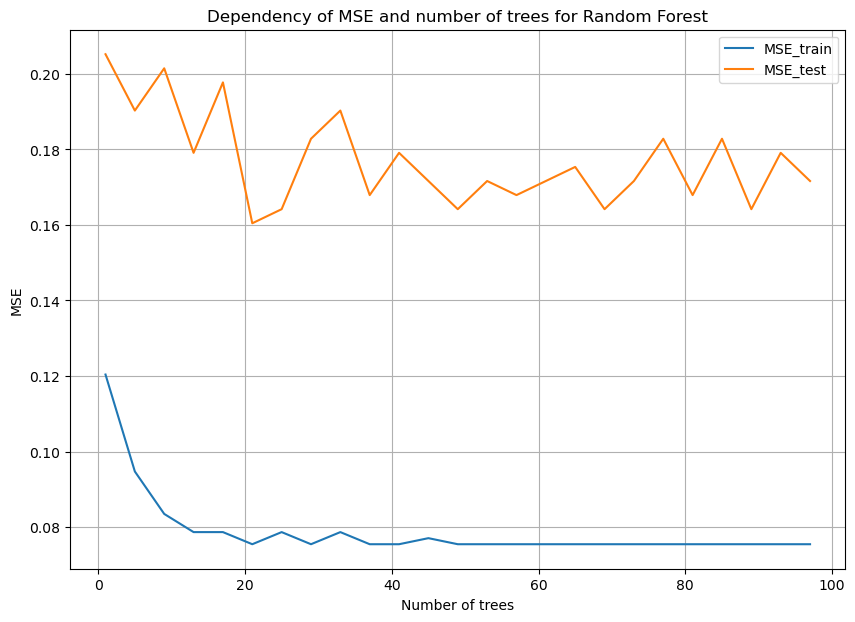

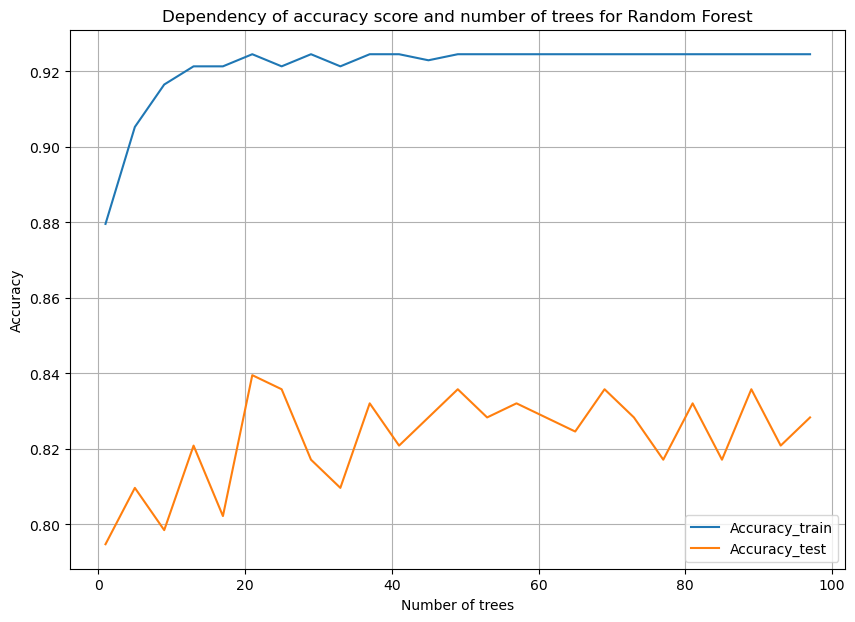

In [787]:
from sklearn.metrics import mean_squared_error

n_trees = range(1, 100, 4)
train_loss = []
test_loss = []
train_accuracy = []
test_accuracy = []

for i in n_trees:
    print(i)
    rf = RandomForestClassifier(n_estimators=i, n_jobs=4)
    rf.fit(X_train, y_train)
    train_loss.append(mean_squared_error(y_train, rf.predict(X_train)))
    test_loss.append(mean_squared_error(y_test, rf.predict(X_test)))
    train_accuracy.append(accuracy_score(y_train, rf.predict(X_train)))
    test_accuracy.append(accuracy_score(y_test, rf.predict(X_test)))

print(min(train_loss))
print(min(test_loss))
print(max(train_accuracy))
print(max(test_accuracy))
print(n_trees[train_loss.index(min(train_loss))])
print(n_trees[test_loss.index(min(test_loss))])
print(n_trees[train_accuracy.index(max(train_accuracy))])
print(n_trees[test_accuracy.index(max(test_accuracy))])

plt.figure(figsize=(10, 7))
plt.title("Dependency of MSE and number of trees for Random Forest")
plt.grid()
plt.plot(n_trees, train_loss, label="MSE_train")
plt.plot(n_trees, test_loss, label="MSE_test")
plt.ylabel("MSE")
plt.xlabel("Number of trees")
plt.legend();

plt.figure(figsize=(10, 7))
plt.title("Dependency of accuracy score and number of trees for Random Forest")
plt.grid()
plt.plot(n_trees, train_accuracy, label="Accuracy_train")
plt.plot(n_trees, test_accuracy, label="Accuracy_test")
plt.ylabel("Accuracy")
plt.xlabel("Number of trees")
plt.legend();

**Answer** On the seminar, we conducted similar experiment through calculating the MSE, and here I also add accuracy score to the experiment. The best quality (measured by its accuracy) of the Random Forests classifier model for the train data is 0.9245585874799358, with smallest MSE being 0.0754414125200642. For test data, the best quality is 0.8395522388059702, and smallest MSE is equal to 0.16044776119402984. The best quality for train data is achieved with approximately 21 (the minimal), 29, 35-41, and 49-100 trees (in this interval the quality is the same). The smallest MSE for train data is achieved with the same amounts of trees, which is logical. The best quality for test data is achieved with 21 trees. The smallest MSE for train data is achieved with the same amount of trees, which is also logical. In both cases correspondence between best quality and smallest MSE is manifested. 

And the same experiment using `AdaBoost` (set `algorithm='SAMME'` as hyperparameter to avoid warnings), draw conclusions

1
5
9
13
17
21
25
29
33
37
41
45
49
53
57
61
65
69
73
77
81
85
89
93
97
0.19743178170144463
0.20149253731343283
0.8025682182985554
0.7985074626865671


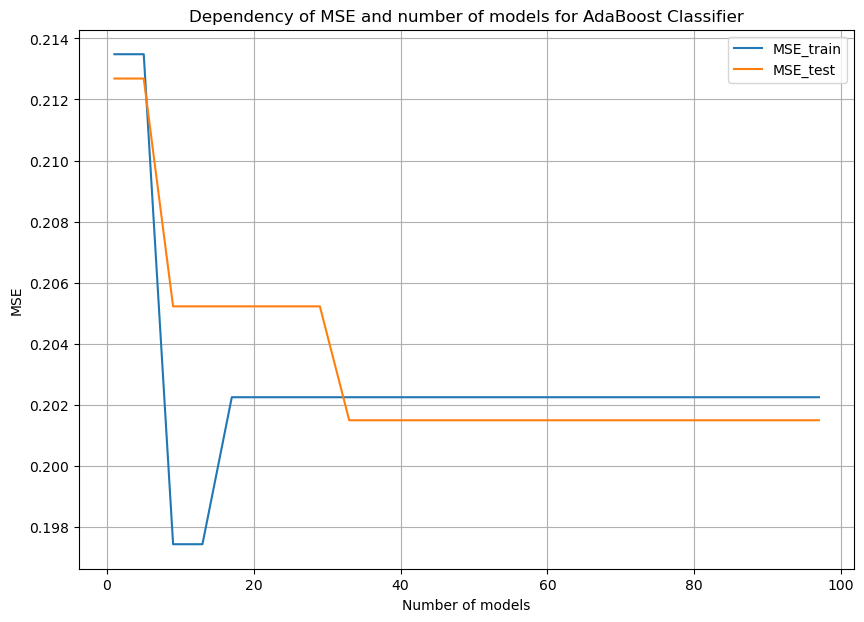

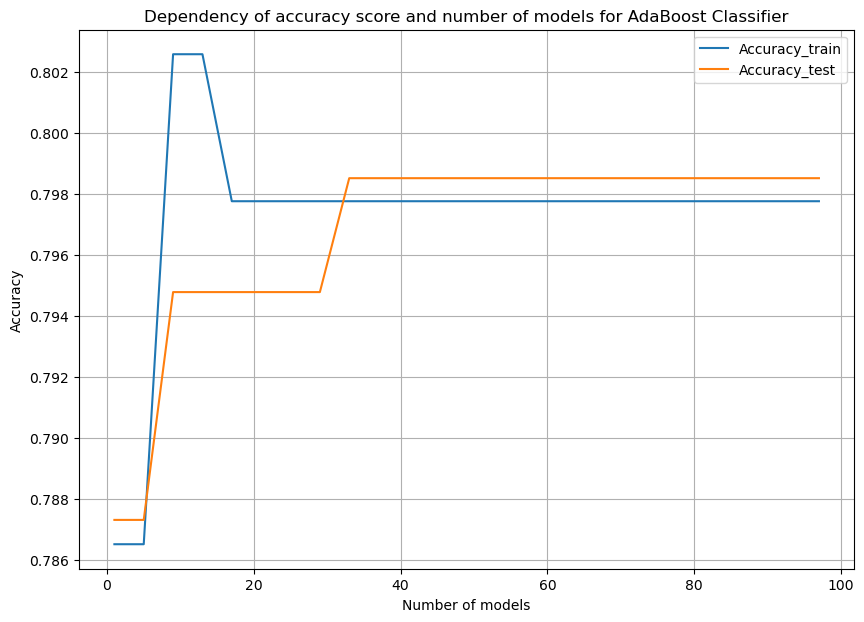

In [790]:
from sklearn.ensemble import AdaBoostClassifier

n_trees = range(1, 100, 4)
train_loss = []
test_loss = []
train_accuracy = []
test_accuracy = []

for i in n_trees:
    print(i)
    ada = AdaBoostClassifier(n_estimators=i, algorithm = 'SAMME')
    ada.fit(X_train, y_train)
    train_loss.append(mean_squared_error(y_train, ada.predict(X_train)))
    test_loss.append(mean_squared_error(y_test, ada.predict(X_test)))
    train_accuracy.append(accuracy_score(y_train, ada.predict(X_train)))
    test_accuracy.append(accuracy_score(y_test, ada.predict(X_test)))
    
print(min(train_loss))
print(min(test_loss))
print(max(train_accuracy))
print(max(test_accuracy))

plt.figure(figsize=(10, 7))
plt.title("Dependency of MSE and number of models for AdaBoost Classifier")
plt.grid()
plt.plot(n_trees, train_loss, label="MSE_train")
plt.plot(n_trees, test_loss, label="MSE_test")
plt.ylabel("MSE")
plt.xlabel("Number of models")
plt.legend();

plt.figure(figsize=(10, 7))
plt.title("Dependency of accuracy score and number of models for AdaBoost Classifier")
plt.grid()
plt.plot(n_trees, train_accuracy, label="Accuracy_train")
plt.plot(n_trees, test_accuracy, label="Accuracy_test")
plt.ylabel("Accuracy")
plt.xlabel("Number of models")
plt.legend();

With how many models the best train quality is achived? What the test quality will be?

In [792]:
print(min(train_loss))
print(min(test_loss))
print(max(train_accuracy))
print(max(test_accuracy))
print(n_trees[train_loss.index(min(train_loss))])
print(n_trees[test_loss.index(min(test_loss))])
print(n_trees[train_accuracy.index(max(train_accuracy))])
print(n_trees[test_accuracy.index(max(test_accuracy))])

0.19743178170144463
0.20149253731343283
0.8025682182985554
0.7985074626865671
9
33
9
33


**Answer** For the AdaBoost classifier experiment, I also add accuracy score in addition to MSE calculation. The best quality (measured by accuracy of predictions) of the model for the train data is 0.8025682182985554, with smallest MSE being 0.19743178170144463. For test data, the best quality is 0.7985074626865671, and smallest MSE is equal to 0.20149253731343283. Results are a bit worse than ones compared to Random Forest classifier, but are still quite good. The best quality for train data is achieved with approximately from 10 to 14 models (in this interval, the quality remains the same), and for the test data it achieved above the threshold of approxiamtely 33 models (than is, every number from approximately 33 to 100 brings about the same quality). As it was the case with Random Forest classifier, the best quality is perfectly corresponding to the smallest MSE in terms of how many models are needed to achieve it.
After conducting the precise search for the numbers of models correspoding to best MSE's and quality (can be seen above), it was indeed 33 models for test data, and starting from 9 (and ending, probably, at 14 once again) models for training data.

# Task 6 (1 point)

What is the best quality achived? Which model did achive it? Whith which hyperparameters? Does it seem logical?

**Answer** Logistic regression had brought us accuracy score of 0.7913322632423756 for train data and 0.7947761194029851 for test data. Logistic regression with tuned hyperparameter (the best of which happened to be equal to 7.880462815669905) had given us a small increase in quality for train data with accuracy score of 0.7929373996789727, and for test data gave us an identical score as for Logistic regression, that is, of 0.7947761194029851. Decision Tree classifier (with max_depth = 5, min_samples_split = 10) had brough us the quality of 0.8330658105939005 measured by accuracy score for training data and for testing data 0.7798507462686567, which is slightly worse that for Logistic regression. Applying soft voting strategy with Logistic regression and Decision Tree classifiers with the same hyperparameters had brough us quality of 0.8298555377207063 for train data and of 0.7985074626865671 for test data, which was quite an increase. AdaBoost classifier gave us 0.8025682182985554 (from 9 to approxiamately 14 models) accuracy score for train data and 0.7985074626865671 for test data (33 models), which was slightly worse that what soft voting with Logistic regression and Decision Tree classifier gave us. At last, Random Forest classifier gave us the best results. RFC with default number of trees returned quality of 0.9245585874799358 for training data and 0.832089552238806 for testing data. After conducting the out experiment with various amounts of trees, we established that 21 (the minimal), 29, 35-41, and 49-100 trees equally give the best quality of 0.9245585874799358 for training data, and 21 trees returned quality of 0.8395522388059702 for test data. This was slightly better that the default number of trees. This is logical, since Decision Tree classifier already gave us quite good results, and since Random Forests technique aggregates multiple decision trees and handles well the outliers and does not allow for significant overfitting.